# 18 — Analisi per cluster delle lunghezze dei riassunti, prima e dopo il contenimento

Questo notebook **non genera nulla**: legge i file di metriche già salvati in `results/metrics/`
(colonna `parole_generate`) e li incrocia con `data/tab/complete.tab` per rispondere a una domanda
che le medie aggregate per metodo (55 parole per `bart` → 477 per `lda`, viste nel notebook [05b](05b_confronto_test.ipynb)) non
coprono — **dentro un singolo cluster Multi-News**, quanto sono diversi fra loro i riassunti dei
18 metodi, e quanto si avvicinano al riassunto di riferimento di quel cluster?

Origine: richiesta del relatore di verificare le lunghezze e, in caso di disomogeneità
significative, contenere la distribuzione dentro un intervallo comune — dettagli e decisioni in
[issue #15](https://github.com/girasella/multi-news-ai4stem-polito-master/issues/15) (sostituisce la #14, che aveva individuato il problema ma solo per
`lda`/notebook [15](15_lsa.ipynb)-[17](17_lda.ipynb)). Il contenimento che ne è seguito — budget per cluster pari alla lunghezza
del riferimento, tetto a 1,25× per tutti e 18, rigenerazione a budget per 15 metodi — è la
[issue #16](https://github.com/girasella/multi-news-ai4stem-polito-master/issues/16).

La stessa analisi gira su **due ambiti** e li mette uno accanto all'altro:

| ambito | ruolo | che cosa contiene |
|---|---|---|
| `test` | **prima** | i riassunti così come ogni metodo li genera (il confronto principale, notebook [05b](05b_confronto_test.ipynb)) |
| `test_budgetref` | **dopo** | gli stessi cluster a lunghezza del riferimento: 15 metodi rigenerati a budget, tetto a 1,25× su tutti e 18 (notebook [05c](05c_confronto_test_budgetref.ipynb)) |

L'ambito `test` è l'analisi *a monte* che ha motivato il contenimento; `test_budgetref` ne è la
misura *a valle* — la dispersione residua (Vista 1) e la quota di cluster in banda per metodo
(Vista 3). Il prima/dopo delle **metriche** (ROUGE, BERTScore, G-Eval) è invece nel notebook [05d](05d_confronto_prima_dopo.ipynb),
che legge da qui la quota in banda.

Quattro cose vengono calcolate, tutte a partire da file già committati:

1. **Dispersione dentro ciascun cluster** — spread (max − min), rapporto max/min, coefficiente di
   variazione, spread rapportato alla lunghezza del riferimento; per ciascun ambito.
2. **Per metodo** — distribuzione di `lunghezza / riferimento`, quota di cluster dentro la banda
   obiettivo, e quanto la lunghezza generata segue quella del riferimento (e il numero di
   articoli del cluster) — prima del contenimento, nella maggior parte dei metodi, non lo fa.
3. **`T(n_articoli)`** — la mediana della lunghezza del riferimento per numero di articoli del
   cluster, tarata sulla split **train**: il primo candidato naturale a budget per-cluster.
4. **Confronto dei predittori del budget** — quanto bene la lunghezza del riferimento si lascia
   prevedere dal solo input (numero di articoli, lunghezza della sorgente, entrambi), contro un
   budget costante e contro il riferimento stesso. È la sezione che ha deciso *quale* budget usare
   per il contenimento, e la risposta non è quella che ci si aspettava.

Le lunghezze sono conteggi di parole (`str.split()`, tokenizer-free — la convenzione usata in
tutto il repository), già presenti in `parole_generate` in ogni CSV per-esempio: nessun riassunto
viene rigenerato né alcuna metrica ricalcolata qui.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
BUDGET_PATH = BASE / 'scripts' / 'budget_lunghezza.json'
su.stile_grafici()

# I due ambiti analizzati, nell'ordine in cui vengono presentati: 'test' e' il
# "prima" (riassunti come generati), 'test_budgetref' il "dopo" (contenimento a
# lunghezza del riferimento, issue #16). Se il secondo non e' ancora stato prodotto
# il notebook gira sul solo 'test'. Ogni ambito scrive il proprio
# analisi_lunghezze_{ambito}.json (quello di test_budgetref e' letto dal notebook 05d).
SCOPI = {'test': 'prima', 'test_budgetref': 'dopo'}
SPLIT_RIFERIMENTI = 'test'   # split di complete.tab da cui leggere i riferimenti

# I cluster con almeno questo numero di articoli condividono l'ultimo bucket di
# T(n_articoli): oltre, il campione per bucket diventa troppo piccolo per una
# mediana stabile (22 cluster a 8+ sulla sola split test, 304 su train).
BUCKET_MASSIMO = 8

# Banda obiettivo attorno alla lunghezza del riferimento, che e' il budget scelto
# per il contenimento (issue #16). Il bordo inferiore e' quanto il solo troncamento
# non potra' mai raggiungere per i metodi piu' corti; quello superiore e' il tetto
# applicato da scripts/applica_budget.py.
BANDA = (0.80, 1.25)
PERCENTILI = (10, 25, 50, 75, 90)

# Palette e costanti condivise con i notebook 05a-05d (definite in summ_utils):
# l'identita' visiva di un metodo resta la stessa in tutto il benchmark.
COLORI = su.COLORI_METODI
INK, INK2, MUTED, GRID, SURFACE = su.INK, su.INK2, su.MUTED, su.GRID, su.SURFACE

print('Ambiti analizzati: ' + ', '.join(f"'{s}' ({ruolo})" for s, ruolo in SCOPI.items())
      + f" — split riferimenti: '{SPLIT_RIFERIMENTI}'")

Ambiti analizzati: 'test' (prima), 'test_budgetref' (dopo) — split riferimenti: 'test'


## Caricamento

Le lunghezze generate vengono dai CSV per-esempio già scritti da `summ_utils.valuta_e_salva`
(colonna `parole_generate`), un insieme per ambito; i file G-Eval non hanno quella colonna e
restano esclusi dal solo fatto di non corrispondere al pattern. Per l'ambito `test_budgetref` si
legge anche, dagli aggregati, quali metodi sono stati **rigenerati a budget** e quali hanno
ricevuto il solo tetto (`bart`, `pegasus`, `primera`): la distinzione serve alla Vista 1.

**Le lunghezze dell'ambito `test_budgetref` sono post-tetto.** I CSV di quell'ambito li scrive
per ultimo `scripts/applica_budget.py`, che tronca ogni riassunto a 1,25× il riferimento e poi
ri-valuta: `parole_generate` è quindi `min(lunghezza generata, tetto)` per tutti e 18 i metodi,
ed è la lunghezza dei testi su cui sono calcolate le metriche dei notebook [05c](05c_confronto_test_budgetref.ipynb)/[05d](05d_confronto_prima_dopo.ipynb) e il G-Eval
a budget. I testi *prima* del tetto sopravvivono solo nei TSV `results/summaries/*_test_budgetref.tsv`
dei 15 metodi rigenerati: la Vista 3b li legge per misurare quanto ciascun metodo rispetta il
budget *da solo*.
Riferimento, numero di articoli e lunghezza della sorgente per cluster vengono da un'unica
scansione in streaming di `complete.tab` (~1 minuto), sulla split analizzata **e** sulla split
train: la seconda serve a tarare i candidati a budget senza usare le etichette su cui poi si
misura.

In [2]:
def carica_lunghezze(metrics_dir, scope):
    """{metodo: {row_id: parole}} dai CSV per-esempio committati di `scope`."""
    suffisso = f'_{scope}_per_example.csv'
    dati = {}
    for path in sorted(Path(metrics_dir).glob(f'*{suffisso}')):
        metodo = path.name[:-len(suffisso)]
        per_riga = {}
        with open(path, encoding='utf-8', newline='') as f:
            for riga in pd.read_csv(f, usecols=['row_id', 'parole_generate']).itertuples():
                per_riga[int(riga.row_id)] = int(riga.parole_generate)
        if per_riga:
            dati[metodo] = per_riga
    return dati


def metodi_rigenerati(metrics_dir, scope):
    """I metodi il cui aggregato di `scope` dichiara la rigenerazione a budget.

    Il flag lo scrive ciascun notebook di generazione (config['ambito_budget']);
    i metodi a solo tetto (applica_budget.py) non ce l'hanno.
    """
    rigenerati = set()
    for path in Path(metrics_dir).glob(f'*_{scope}_aggregate.json'):
        with open(path, encoding='utf-8') as f:
            config = json.load(f).get('config', {})
        if config.get('ambito_budget', {}).get('rigenerato_a_budget'):
            rigenerati.add(path.name[:-len(f'_{scope}_aggregate.json')])
    return rigenerati


def scansiona_complete_tab(path, splits):
    """Un'unica passata in streaming.

    -> {split: [(row_id, n_articoli, parole_riferimento, parole_sorgente)]}

    Il numero di articoli si conta sul documento GREZZO (separatore '|||||'): dopo
    `prepara_documento` il separatore e' diventato un newline, indistinguibile dai
    newline interni a un articolo. La sorgente e' contata con il separatore tolto.
    """
    voluti = set(splits)
    out = {s: [] for s in splits}
    for es in su.itera_complete_tab(path):
        if es['split'] not in voluti:
            continue
        doc = es['document']
        n_articoli = doc.count(su.SEPARATORE_ARTICOLI) + 1
        parole_rif = len(su.pulisci_riferimento(es['summary']).split())
        parole_src = len(doc.replace(su.SEPARATORE_ARTICOLI, ' ').split())
        out[es['split']].append((es['row_id'], n_articoli, parole_rif, parole_src))
    return out


lunghezze = {}
for scope in SCOPI:
    dati = carica_lunghezze(P['metrics_dir'], scope)
    if dati:
        lunghezze[scope] = dati
        print(f"Ambito '{scope}': {len(dati)} metodi -> {sorted(dati)}")
    else:
        print(f"Ambito '{scope}': nessun CSV per-esempio trovato, saltato")
SCOPI = {s: r for s, r in SCOPI.items() if s in lunghezze}

rigenerati = metodi_rigenerati(P['metrics_dir'], 'test_budgetref')
if 'test_budgetref' in lunghezze:
    solo_tetto = sorted(set(lunghezze['test_budgetref']) - rigenerati)
    print(f"Ambito 'test_budgetref': {len(rigenerati)} metodi rigenerati a budget, "
          f"{len(solo_tetto)} col solo tetto ({', '.join(solo_tetto)})")

# Lunghezze PRE-tetto dei metodi rigenerati a budget, dai TSV di riassunti (stesso
# conteggio di parole_generate: str.split()). Solo per la Vista 3b.
lunghezze_pre_tetto = {}
for path in sorted(P['summaries_dir'].glob('*_test_budgetref.tsv')):
    metodo = path.name[:-len('_test_budgetref.tsv')]
    if metodo in rigenerati:
        lunghezze_pre_tetto[metodo] = {rid: len(testo.split())
                                       for rid, testo in su.carica_riassunti(path).items()}
print(f"Riassunti pre-tetto letti per {len(lunghezze_pre_tetto)} metodi rigenerati")

split_da_leggere = [SPLIT_RIFERIMENTI] + (['train'] if SPLIT_RIFERIMENTI != 'train' else [])
print(f"Scansione di {P['complete_tab'].name} (split: {', '.join(split_da_leggere)})...")
righe = scansiona_complete_tab(P['complete_tab'], split_da_leggere)
print(', '.join(f"{len(v)} cluster (split '{s}')" for s, v in righe.items()))

Ambito 'test': 18 metodi -> ['bart', 'centroid_mmr', 'centroid_mmr_bert', 'firstk_nltk', 'firstk_psr', 'gemma', 'gpt5mini', 'lda', 'lexrank', 'lsa', 'lsa_steinberger', 'mistral', 'pegasus', 'primera', 'qwen', 'sbert_agglom', 'sbert_kmeans', 'textrank']


Ambito 'test_budgetref': 18 metodi -> ['bart', 'centroid_mmr', 'centroid_mmr_bert', 'firstk_nltk', 'firstk_psr', 'gemma', 'gpt5mini', 'lda', 'lexrank', 'lsa', 'lsa_steinberger', 'mistral', 'pegasus', 'primera', 'qwen', 'sbert_agglom', 'sbert_kmeans', 'textrank']
Ambito 'test_budgetref': 15 metodi rigenerati a budget, 3 col solo tetto (bart, pegasus, primera)


Riassunti pre-tetto letti per 15 metodi rigenerati
Scansione di complete.tab (split: test, train)...


5610 cluster (split 'test'), 44880 cluster (split 'train')


## Il candidato naturale: `T(n_articoli)`

Il riassunto di riferimento non ha una lunghezza costante: cresce con il numero di articoli del
cluster. `T(n_articoli)` — la mediana del riferimento per bucket di articoli — è quindi il primo
candidato che viene in mente come budget di parole per-cluster. **Tarato sulla split train**,
così le etichette della split test non entrano nel budget con cui poi si misura.

Se `scripts/budget_lunghezza.json` esiste già, questa cella lo riusa invece di ricalcolarlo — la
tabella è un **parametro** del benchmark, non un output da rigenerare a ogni esecuzione. Se sia
davvero il budget giusto lo decide la Vista 5, più sotto.


In [3]:
def tabella_budget(righe_train, bucket_massimo=BUCKET_MASSIMO):
    per_bucket = defaultdict(list)
    for _, n_articoli, parole_rif, _ in righe_train:
        per_bucket[min(n_articoli, bucket_massimo)].append(parole_rif)
    tabella = {str(n): int(round(float(np.median(v)))) for n, v in sorted(per_bucket.items())}
    conteggi = {str(n): len(v) for n, v in sorted(per_bucket.items())}
    return tabella, conteggi


if not BUDGET_PATH.exists():
    T, conteggi_T = tabella_budget(righe['train'])
    BUDGET_PATH.write_text(json.dumps({
        'descrizione': 'T(n_articoli): mediana della lunghezza (parole) del riassunto di '
                       'riferimento per numero di articoli del cluster (issue #15).',
        'split_di_taratura': 'train', 'bucket_massimo': BUCKET_MASSIMO, 'banda': list(BANDA),
        'n_cluster_per_bucket': conteggi_T, 'tabella': T,
    }, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Tabella budget scritta: {BUDGET_PATH}')
else:
    contenuto = json.loads(BUDGET_PATH.read_text(encoding='utf-8'))
    T, conteggi_T = contenuto['tabella'], contenuto['n_cluster_per_bucket']
    print(f'Tabella budget riusata da {BUDGET_PATH} (gia\' presente)')

tabella_T = pd.DataFrame({'T (parole)': T, 'n_cluster (train)': conteggi_T})
tabella_T.index.name = 'n_articoli'
display(tabella_T)


Tabella budget riusata da C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\scripts\budget_lunghezza.json (gia' presente)


,T (parole),n_cluster (train)
n_articoli,,
1,164,458
2,194,23703
3,232,12574
4,250,4918
5,270,1845
6,287,707
7,304,371
8,327,304


## Analisi

Ristretta, **ambito per ambito**, ai `row_id` coperti da tutti i metodi trovati per quell'ambito
(stessa logica di intersezione dei notebook [05b](05b_confronto_test.ipynb) e [05c](05c_confronto_test_budgetref.ipynb)). Le due intersezioni non coincidono
(la copertura del content filter di Azure cambia fra una corsa e l'altra: 5.437 cluster su
`test`, 5.527 su `test_budgetref`), ma le distribuzioni sono su migliaia di cluster e la
differenza di insieme non sposta i percentili.

Il rapporto max/min dentro il cluster viene calcolato anche su due sottoinsiemi di metodi:
**senza `bart`** (l'eccezione dichiarata: a solo tetto e a 0,26× il riferimento, è il minimo di
quasi ogni cluster) e sui **soli metodi rigenerati a budget** — è su questi che il contenimento
va giudicato.

In [4]:
def distribuzione(valori, cifre=2):
    a = np.asarray(valori, dtype=np.float64)
    d = {f'p{p}': round(float(np.percentile(a, p)), cifre) for p in PERCENTILI}
    d.update(media=round(float(a.mean()), cifre), min=round(float(a.min()), cifre),
             max=round(float(a.max()), cifre), n=int(a.size))
    return d


def pearson(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size < 2 or x.std() == 0 or y.std() == 0:
        return None
    return round(float(np.corrcoef(x, y)[0, 1]), 3)


def budget_riga(n_articoli, tabella=T, bucket_massimo=BUCKET_MASSIMO):
    return tabella[str(min(n_articoli, bucket_massimo))]


def rapporto_max_min_per_cluster(lunghezze_scope, comuni, metodi):
    """Rapporto max/min della lunghezza dentro ogni cluster, sui soli `metodi`."""
    out = []
    for row_id in comuni:
        L = np.array([lunghezze_scope[m][row_id] for m in metodi], dtype=np.float64)
        out.append(L.max() / max(L.min(), 1.0))
    return np.asarray(out)


def analizza(lunghezze_scope, riferimento):
    """Dispersione per cluster e distribuzioni per metodo di un ambito.

    `comuni` e' l'intersezione dei row_id fra tutti i metodi dell'ambito e il
    riferimento; R/A/B sono, in quell'ordine, parole del riferimento, numero di
    articoli e budget T(n_articoli) per ciascun cluster comune.
    """
    metodi = sorted(lunghezze_scope)
    comuni = sorted(set.intersection(*(set(d) for d in lunghezze_scope.values())) & set(riferimento))

    # --- 1. dispersione dentro ciascun cluster ---
    spread, rapporto_max_min, cv, spread_rel = [], [], [], []
    for row_id in comuni:
        L = np.array([lunghezze_scope[m][row_id] for m in metodi], dtype=np.float64)
        parole_rif = riferimento[row_id][1]
        spread.append(L.max() - L.min())
        rapporto_max_min.append(L.max() / max(L.min(), 1.0))
        cv.append(L.std() / L.mean() if L.mean() else 0.0)
        spread_rel.append((L.max() - L.min()) / max(parole_rif, 1))

    dispersione = {'spread_parole': distribuzione(spread, 1),
                   'rapporto_max_min': distribuzione(rapporto_max_min, 2),
                   'cv': distribuzione(cv, 3),
                   'spread_su_riferimento': distribuzione(spread_rel, 2)}

    # --- 2. per metodo ---
    R = np.array([riferimento[r][1] for r in comuni], dtype=np.float64)   # parole riferimento
    A = np.array([riferimento[r][0] for r in comuni], dtype=np.float64)   # numero di articoli
    B = np.array([budget_riga(riferimento[r][0]) for r in comuni], dtype=np.float64)

    per_metodo = {}
    for m in metodi:
        L = np.array([lunghezze_scope[m][r] for r in comuni], dtype=np.float64)
        in_banda = float(((L >= BANDA[0] * R) & (L <= BANDA[1] * R)).mean())   # banda sul riferimento
        per_metodo[m] = {
            'parole': distribuzione(L, 1),
            'rapporto_riferimento': distribuzione(L / np.maximum(R, 1), 2),
            'rapporto_budget': distribuzione(L / B, 2),
            'pct_in_banda': round(100 * in_banda, 1),
            'corr_len_riferimento': pearson(L, R),
            'corr_len_n_articoli': pearson(L, A),
        }

    return {'metodi': metodi, 'comuni': comuni, 'R': R, 'A': A,
            'rapporto_max_min': np.asarray(rapporto_max_min),
            'dispersione': dispersione, 'per_metodo': per_metodo}


riferimento = {row_id: (n_articoli, parole_rif) for row_id, n_articoli, parole_rif, _
               in righe[SPLIT_RIFERIMENTI]}

analisi = {}
for scope in SCOPI:
    analisi[scope] = analizza(lunghezze[scope], riferimento)
    print(f"Ambito '{scope}': {len(analisi[scope]['comuni'])} cluster in comune fra i "
          f"{len(analisi[scope]['metodi'])} metodi e il riferimento")

# Sottoinsiemi di metodi per il rapporto max/min (stessi in entrambi gli ambiti, cosi'
# il prima/dopo confronta gli stessi metodi): tutti, senza bart, solo i rigenerati.
SOTTOINSIEMI = {'tutti i metodi': None, 'senza bart': lambda ms: [m for m in ms if m != 'bart'],
                'solo rigenerati a budget': lambda ms: [m for m in ms if m in rigenerati]}
for scope, a in analisi.items():
    a['rapporto_sottoinsiemi'] = {}
    for nome, filtro in SOTTOINSIEMI.items():
        metodi_sub = a['metodi'] if filtro is None else filtro(a['metodi'])
        if len(metodi_sub) >= 2:
            a['rapporto_sottoinsiemi'][nome] = {
                'n_metodi': len(metodi_sub),
                **distribuzione(rapporto_max_min_per_cluster(lunghezze[scope], a['comuni'], metodi_sub), 2)}

print('Analisi completata.')

Ambito 'test': 5437 cluster in comune fra i 18 metodi e il riferimento


Ambito 'test_budgetref': 5527 cluster in comune fra i 18 metodi e il riferimento


Analisi completata.


## Vista 1 — Dispersione dentro ciascun cluster, prima e dopo

Nel cluster tipico, quanto è diverso il riassunto più lungo dal più corto? Prima del
contenimento, e dopo. La seconda tabella isola il rapporto max/min sui tre insiemi di metodi:
il numero sui 18 sottostima il contenimento, perché `bart` — a solo tetto, 0,26× il
riferimento — resta il minimo di quasi ogni cluster mentre il tetto tiene il massimo a 1,25×
(1,25/0,26 ≈ 4,8); tolto lui, o guardando i soli 15 rigenerati, si vede quanto la dispersione è
stata davvero annullata. Le lunghezze «dopo» sono quelle **post-tetto** (vedi *Caricamento*):
il massimo del cluster non può superare 1,25× il riferimento, quindi il rapporto max/min è
limitato dall'alto dal tetto e dal basso dal metodo più corto.


Dispersione dentro il cluster, su tutti i metodi dell'ambito:


p10      p25  \
prima (test)          spread max-min (parole)         265.000  329.000   
                      rapporto max/min                  5.590    6.840   
                      CV (std/media)                    0.345    0.383   
                      spread / lunghezza riferimento    1.230    1.520   
dopo (test_budgetref) spread max-min (parole)         105.000  150.000   
                      rapporto max/min                  2.860    3.690   
                      CV (std/media)                    0.179    0.195   
                      spread / lunghezza riferimento    0.780    0.870   

                                                          p50      p75  \
prima (test)          spread max-min (parole)         409.000  503.000   
                      rapporto max/min                  8.510   10.580   
                      CV (std/media)                    0.432    0.488   
                      spread / lunghezza riferimento    1.950    2.530   
dopo (test_budgetref) spread max-min (parole)         206.000  258.000   
                      rapporto max/min                  4.710    5.870   
                      CV (std/media)                    0.213    0.231   
                      spread / lunghezza riferimento    0.950    1.020   

                                                          p90    media  \
prima (test)          spread max-min (parole)         609.000  431.700   
                      rapporto max/min                 13.050    9.210   
                      CV (std/media)                    0.546    0.442   
                      spread / lunghezza riferimento    3.260    2.150   
dopo (test_budgetref) spread max-min (parole)         298.000  206.200   
                      rapporto max/min                  6.960    4.870   
                      CV (std/media)                    0.251    0.215   
                      spread / lunghezza riferimento    1.060    0.930   

                                                         min       max  
prima (test)          spread max-min (parole)         48.000  7701.000  
                      rapporto max/min                 2.020   297.190  
                      CV (std/media)                   0.177     1.746  
                      spread / lunghezza riferimento   0.280    25.500  
dopo (test_budgetref) spread max-min (parole)         27.000   666.000  
                      rapporto max/min                 1.470    42.500  
                      CV (std/media)                   0.110     0.814  
                      spread / lunghezza riferimento   0.400     1.220


Rapporto max/min dentro il cluster per insieme di metodi:


n_metodi   p10   p25  mediana    p75    p90
tutti i metodi           prima      18.0  5.59  6.84     8.51  10.58  13.05
                         dopo       18.0  2.86  3.69     4.71   5.87   6.96
senza bart               prima      17.0  2.75  3.20     3.84   4.76   5.91
                         dopo       17.0  1.39  1.47     1.65   1.90   2.31
solo rigenerati a budget prima      15.0  2.66  3.10     3.72   4.61   5.74
                         dopo       15.0  1.29  1.35     1.43   1.57   1.81

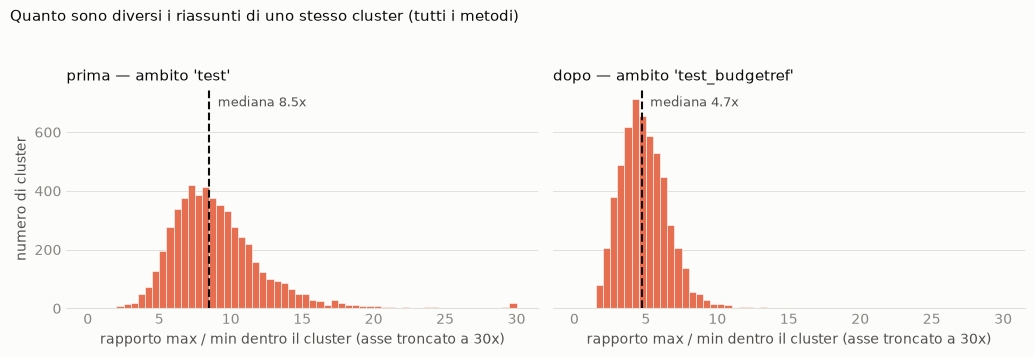

In [5]:
nomi_dispersione = {'spread_parole': 'spread max-min (parole)',
                    'rapporto_max_min': 'rapporto max/min',
                    'cv': 'CV (std/media)',
                    'spread_su_riferimento': 'spread / lunghezza riferimento'}
colonne_dist = [f'p{p}' for p in PERCENTILI] + ['media', 'min', 'max']

blocchi = []
for scope, ruolo in SCOPI.items():
    t = pd.DataFrame({nomi_dispersione[k]: v for k, v in analisi[scope]['dispersione'].items()}).T
    t.index = pd.MultiIndex.from_product([[f'{ruolo} ({scope})'], t.index])
    blocchi.append(t[colonne_dist])
print('Dispersione dentro il cluster, su tutti i metodi dell\'ambito:')
display(pd.concat(blocchi))

righe_sub = {}
for nome in SOTTOINSIEMI:
    for scope, ruolo in SCOPI.items():
        d = analisi[scope]['rapporto_sottoinsiemi'].get(nome)
        if d:
            righe_sub[(nome, ruolo)] = {'n_metodi': d['n_metodi'], 'p10': d['p10'], 'p25': d['p25'],
                                       'mediana': d['p50'], 'p75': d['p75'], 'p90': d['p90']}
print('\nRapporto max/min dentro il cluster per insieme di metodi:')
display(pd.DataFrame(righe_sub).T)

fig, axes = plt.subplots(1, len(SCOPI), figsize=(5.2 * len(SCOPI), 3.6), facecolor=SURFACE,
                         sharey=True, squeeze=False)
for ax, (scope, ruolo) in zip(axes.ravel(), SCOPI.items()):
    ax.set_facecolor(SURFACE)
    rapporto_arr = analisi[scope]['rapporto_max_min']
    ax.hist(np.clip(rapporto_arr, 0, 30), bins=60, range=(0, 30), color='#e76f51',
            edgecolor='white', lw=0.4, zorder=2)
    mediana = float(np.median(rapporto_arr))
    ax.axvline(mediana, color=INK, lw=1.5, ls='--', zorder=3)
    ax.annotate(f'mediana {mediana:.1f}x', (mediana, 0.92), xycoords=('data', 'axes fraction'),
                xytext=(6, 0), textcoords='offset points', fontsize=9, color=INK2)
    ax.set_xlabel('rapporto max / min dentro il cluster (asse troncato a 30x)')
    ax.set_title(f"{ruolo} — ambito '{scope}'", color=INK, loc='left', fontsize=11)
    ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
axes[0, 0].set_ylabel('numero di cluster')
fig.suptitle('Quanto sono diversi i riassunti di uno stesso cluster (tutti i metodi)', color=INK,
             x=0.01, ha='left', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Vista 2 — Il bersaglio non è costante

Lunghezza del riassunto di riferimento sull'ambito analizzato, e come cresce col numero di
articoli del cluster (bucket `T(n_articoli)` calcolati sopra, sulla split train). La tendenza è
reale; quanto sia *utile* per prevedere il singolo cluster lo dice la Vista 5.


Lunghezza del riferimento:


,p10,p25,p50,p75,p90,media,min,max,n
parole riferimento,129.0,167.0,217.0,259.0,292.0,215.5,54.0,615.0,5437.0


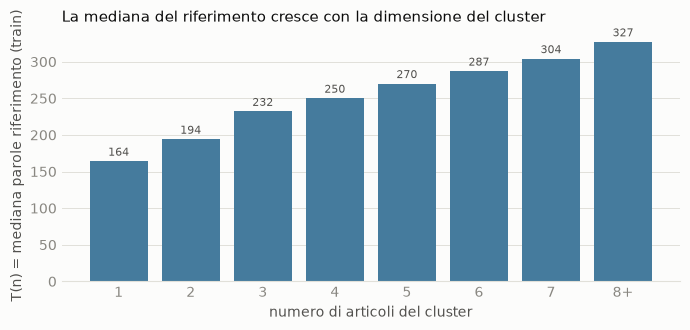

In [6]:
R = analisi['test']['R']    # parole del riferimento sui cluster comuni dell'ambito 'test'
print('Lunghezza del riferimento:')
display(pd.Series(distribuzione(R, 1)).to_frame('parole riferimento').T)

fig, ax = plt.subplots(figsize=(7, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bucket = [int(k) for k in T]
valori_T = [T[str(k)] for k in bucket]
ax.bar([str(k) if k < BUCKET_MASSIMO else f'{k}+' for k in bucket], valori_T,
       color='#457b9d', zorder=2)
for x, v in enumerate(valori_T):
    ax.annotate(str(v), (x, v), xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=8, color=INK2)
ax.set_xlabel('numero di articoli del cluster')
ax.set_ylabel('T(n) = mediana parole riferimento (train)')
ax.set_title('La mediana del riferimento cresce con la dimensione del cluster',
             color=INK, loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

## Vista 3 — Per metodo: prima nessuno si adatta al cluster, dopo quasi tutti

Per ciascun metodo e ciascun ambito: il rapporto `lunghezza generata / lunghezza riferimento`
per cluster (quanto si discosta dal bersaglio), la quota di cluster dentro la banda
`[0,80, 1,25] ×` riferimento — la banda del contenimento (issue #16) — e la correlazione fra la
lunghezza generata e quella del riferimento / il numero di articoli: un metodo che si adattasse
al cluster avrebbe una correlazione alta con entrambi. Prima del contenimento nessuno ce l'ha;
dopo, per i 15 rigenerati la correlazione col riferimento è quasi 1 per costruzione, e la
colonna «in banda % dopo» è la misura diretta di quanto il contenimento ha funzionato per
ciascun metodo. `bart`, `pegasus` e `primera` (solo tetto) restano dove erano.

Anche qui le lunghezze «dopo» sono **post-tetto**: nessun rapporto supera 1,25 (più
l'arrotondamento), e dove il quartile alto o il p90 di un metodo valgono esattamente 1,25
(`mistral`, `lda`, `pegasus`) è il tetto che li schiaccia lì, non una distribuzione che finisce
lì da sola. Quanto quei metodi eccedessero *prima* del taglio lo dice la Vista 3b.


prima                                                                  dopo                                                       
                  parole (media)   p10 mediana   p90 in banda % corr(rif.) corr(n_art.) parole (media)   p10 mediana   p90 in banda % corr(rif.) corr(n_art.)
bart                        55.1  0.17    0.26  0.43        0.3      0.065        0.013           55.2  0.17    0.26  0.43        0.3      0.066        0.015
qwen                       140.3  0.44    0.65  1.07       24.8      0.201        0.113          216.1  0.75    1.01  1.25       79.2      0.820        0.243
mistral                    161.2  0.46    0.75  1.27       33.1      0.161        0.041          232.2  0.77    1.20  1.25       71.3      0.790        0.343
pegasus                    178.1  0.59    0.83  1.26       45.2      0.427        0.145          175.1  0.60    0.83  1.25       52.1      0.544        0.178
firstk_psr                 216.3  0.53    0.96  1.69       37.8      0.273        0.563          214.4  0.93    1.00  1.07       98.0      0.973        0.430
primera                    210.4  0.64    0.97  1.47       52.7      0.507        0.412          201.1  0.64    0.97  1.25       65.9      0.671        0.450
firstk_nltk                218.5  0.54    0.98  1.70       38.8      0.296        0.583          214.4  0.93    1.00  1.06       98.1      0.974        0.436
sbert_agglom               215.8  0.59    0.98  1.82       39.3     -0.075       -0.076          214.5  0.94    1.00  1.06       98.5      0.977        0.435
gpt5mini                   239.7  0.64    1.05  1.87       42.0      0.305        0.280          208.3  0.90    0.96  1.04       99.8      0.979        0.426
lsa                        248.6  0.63    1.16  2.05       36.6     -0.008       -0.027          214.5  0.93    1.00  1.07       98.2      0.975        0.437
lsa_steinberger            257.2  0.73    1.20  2.06       40.2      0.046        0.015          214.8  0.93    1.00  1.07       98.5      0.978        0.439
sbert_kmeans               263.5  0.78    1.21  2.08       41.4      0.139        0.156          214.4  0.93    1.00  1.06       98.1      0.976        0.437
gemma                      291.6  0.88    1.34  2.17       36.5      0.358        0.351          218.3  0.91    1.01  1.12       99.4      0.961        0.385
centroid_mmr               361.3  1.04    1.66  2.82       19.7      0.168        0.212          214.8  0.91    1.00  1.08       97.5      0.968        0.426
centroid_mmr_bert          361.1  1.06    1.66  2.80       18.3      0.177        0.201          214.7  0.92    1.00  1.08       97.5      0.972        0.433
textrank                   367.7  1.07    1.69  2.90       17.5      0.176        0.202          214.8  0.91    1.00  1.08       97.6      0.971        0.435
lexrank                    449.8  1.32    2.06  3.43        6.8      0.224        0.266          215.5  0.90    1.00  1.10       97.2      0.965        0.429
lda                        476.6  1.43    2.16  3.56        4.1      0.272        0.320          229.3  0.89    1.07  1.25       93.4      0.922        0.437

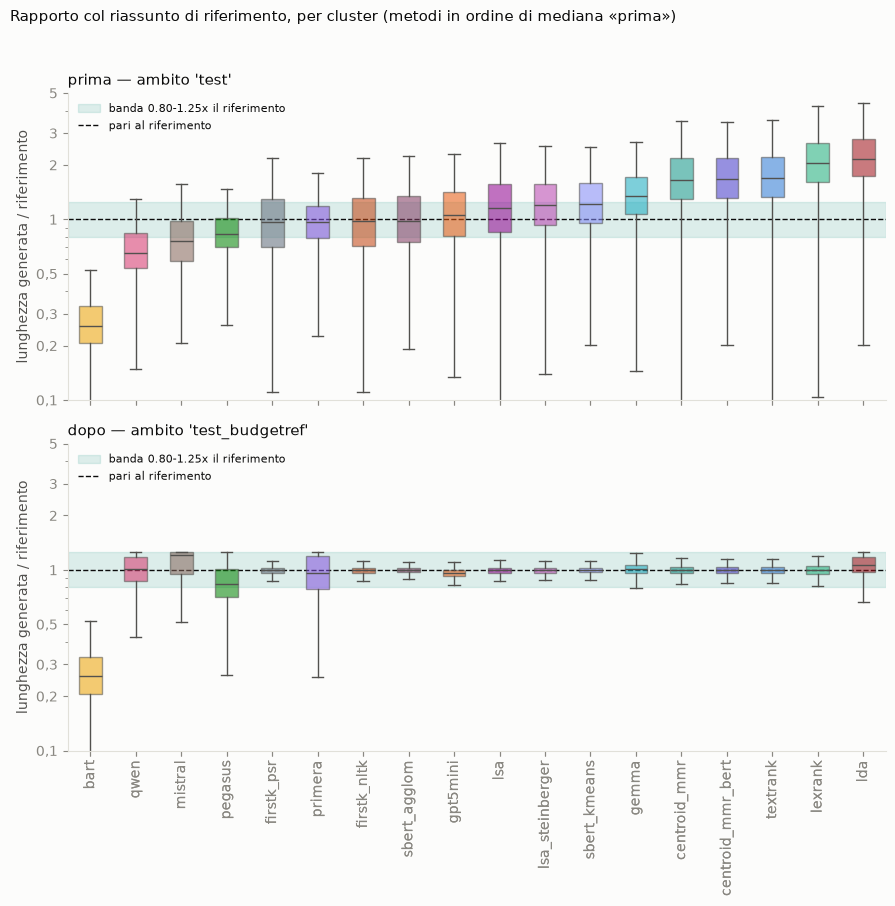

In [7]:
righe_tabella = {}
for scope, ruolo in SCOPI.items():
    for m, d in analisi[scope]['per_metodo'].items():
        r = d['rapporto_riferimento']
        righe_tabella.setdefault(m, {}).update({
            (ruolo, 'parole (media)'): d['parole']['media'],
            (ruolo, 'p10'): r['p10'], (ruolo, 'mediana'): r['p50'], (ruolo, 'p90'): r['p90'],
            (ruolo, 'in banda %'): d['pct_in_banda'],
            (ruolo, 'corr(rif.)'): d['corr_len_riferimento'],
            (ruolo, 'corr(n_art.)'): d['corr_len_n_articoli'],
        })
tabella_metodi = pd.DataFrame(righe_tabella).T.sort_values(('prima', 'mediana'))
tabella_metodi.columns = pd.MultiIndex.from_tuples(tabella_metodi.columns)
with pd.option_context('display.max_columns', None, 'display.width', 250):
    display(tabella_metodi)

ordinati = list(tabella_metodi.index)
fig, axes = plt.subplots(len(SCOPI), 1, figsize=(9, 4.6 * len(SCOPI)), facecolor=SURFACE,
                         sharex=True, squeeze=False)
for ax, (scope, ruolo) in zip(axes.ravel(), SCOPI.items()):
    a = analisi[scope]
    ax.set_facecolor(SURFACE)
    serie = [np.array([lunghezze[scope][m][r] for r in a['comuni']], dtype=np.float64)
             / np.maximum(a['R'], 1) for m in ordinati]
    ax.axhspan(BANDA[0], BANDA[1], color='#2a9d8f', alpha=0.15,
               label=f'banda {BANDA[0]:.2f}-{BANDA[1]:.2f}x il riferimento', zorder=1)
    ax.axhline(1.0, color=INK, lw=1, ls='--', label='pari al riferimento', zorder=1)
    bp = ax.boxplot(serie, showfliers=False, tick_labels=ordinati, patch_artist=True, zorder=2)
    for patch, m in zip(bp['boxes'], ordinati):
        patch.set_facecolor(COLORI.get(m, MUTED))
        patch.set_alpha(0.55)
        patch.set_edgecolor(INK2)
    for elem in ('whiskers', 'caps', 'medians'):
        for line in bp[elem]:
            line.set_color(INK2)
    ax.set_yscale('log')
    ax.set_ylim(0.1, 5)
    ax.set_yticks([0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5], ['0,1', '0,2', '0,3', '0,5', '1', '2', '3', '5'])
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_ylabel('lunghezza generata / riferimento')
    ax.set_title(f"{ruolo} — ambito '{scope}'", color=INK, loc='left', fontsize=11)
    ax.tick_params(axis='y', colors=MUTED)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper left', fontsize=8, frameon=False)
axes[-1, 0].tick_params(axis='x', rotation=90, colors=MUTED)
fig.suptitle('Rapporto col riassunto di riferimento, per cluster (metodi in ordine di mediana «prima»)',
             color=INK, x=0.01, ha='left', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Vista 3b — La rigenerazione da sola, prima del tetto

Per i 15 metodi rigenerati a budget: la lunghezza che il metodo ha prodotto **prima** che
`applica_budget.py` applicasse il tetto, letta dai TSV di riassunti. È la misura di quanto
ciascun metodo rispetta il budget *da solo* — per gli estrattivi, quanto la regola della frase
«a cavallo» (`su.seleziona_per_budget`) centra il conteggio di parole; per gli LLM, quanto
seguono l'istruzione di lunghezza nel prompt con il fattore calibrato per modello
(`FATTORE_RICHIESTA`: qwen 1,2, mistral 1,0, gemma e gpt5mini 0,9).

Le tre colonne di quota si leggono insieme: «sotto banda» (< 0,80×) è ciò che il tetto non
può correggere e resta fuori banda anche nella Vista 3; «sopra tetto» (> 1,25×) sono le righe
che il tetto ha effettivamente tagliato — nella Vista 3 compaiono *in banda*, al bordo 1,25.
Il boxplot mostra la distribuzione completa, baffi e outlier compresi, senza il taglio.

Rigenerazione a budget prima del tetto, 5527 cluster comuni (rapporto lunghezza / riferimento):


,parole (media),p10,mediana,p90,max,sotto banda %,in banda %,sopra tetto %,in banda % post-tetto
qwen,221.6,0.75,1.01,1.33,2.51,15.1,69.0,15.9,79.2
mistral,281.0,0.77,1.20,1.98,7.32,12.3,41.7,46.0,71.3
firstk_psr,214.5,0.93,1.00,1.07,2.26,1.7,97.6,0.7,98.0
firstk_nltk,214.6,0.93,1.00,1.06,2.26,1.7,97.5,0.8,98.1
sbert_agglom,214.7,0.94,1.00,1.06,4.21,1.4,98.2,0.5,98.5
gpt5mini,208.4,0.90,0.96,1.04,1.54,0.1,99.5,0.4,99.8
lsa,214.9,0.93,1.00,1.07,5.80,1.6,97.7,0.7,98.2
lsa_steinberger,215.2,0.93,1.00,1.07,5.80,1.2,98.0,0.8,98.5
sbert_kmeans,214.5,0.93,1.00,1.06,1.85,1.7,97.8,0.5,98.1
gemma,218.4,0.91,1.01,1.12,1.45,0.3,99.1,0.6,99.4


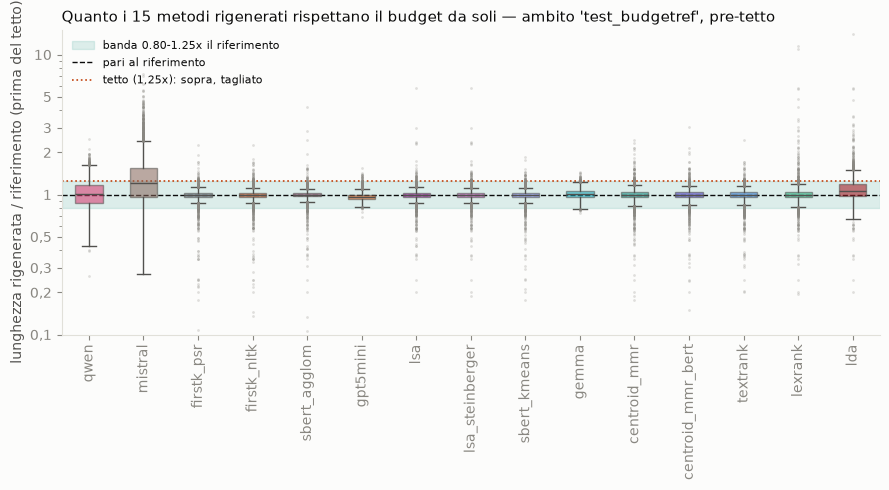

In [8]:
a_dopo = analisi.get('test_budgetref')
if a_dopo and lunghezze_pre_tetto:
    R_dopo, comuni_dopo = a_dopo['R'], a_dopo['comuni']
    ordine_pre = [m for m in ordinati if m in lunghezze_pre_tetto]   # stesso ordine della Vista 3
    pre_tetto = {}
    serie_pre = []
    for m in ordine_pre:
        L = np.array([lunghezze_pre_tetto[m][r] for r in comuni_dopo], dtype=np.float64)
        rapporto = L / np.maximum(R_dopo, 1)
        serie_pre.append(rapporto)
        pre_tetto[m] = {
            'parole': distribuzione(L, 1),
            'rapporto_riferimento': distribuzione(rapporto, 2),
            'pct_sotto_banda': round(100 * float((rapporto < BANDA[0]).mean()), 1),
            'pct_in_banda': round(100 * float(((rapporto >= BANDA[0]) & (rapporto <= BANDA[1])).mean()), 1),
            'pct_sopra_tetto': round(100 * float((rapporto > BANDA[1]).mean()), 1),
            'corr_len_riferimento': pearson(L, R_dopo),
        }

    tabella_pre = pd.DataFrame({m: {
        'parole (media)': d['parole']['media'],
        'p10': d['rapporto_riferimento']['p10'], 'mediana': d['rapporto_riferimento']['p50'],
        'p90': d['rapporto_riferimento']['p90'], 'max': d['rapporto_riferimento']['max'],
        'sotto banda %': d['pct_sotto_banda'], 'in banda %': d['pct_in_banda'],
        'sopra tetto %': d['pct_sopra_tetto'],
        'in banda % post-tetto': a_dopo['per_metodo'][m]['pct_in_banda'],
    } for m, d in pre_tetto.items()}).T
    print(f"Rigenerazione a budget prima del tetto, {len(comuni_dopo)} cluster comuni "
          f"(rapporto lunghezza / riferimento):")
    with pd.option_context('display.max_columns', None, 'display.width', 250):
        display(tabella_pre)

    fig, ax = plt.subplots(figsize=(9, 5), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.axhspan(BANDA[0], BANDA[1], color='#2a9d8f', alpha=0.15,
               label=f'banda {BANDA[0]:.2f}-{BANDA[1]:.2f}x il riferimento', zorder=1)
    ax.axhline(1.0, color=INK, lw=1, ls='--', label='pari al riferimento', zorder=1)
    ax.axhline(BANDA[1], color='#c2410c', lw=1.2, ls=':', label='tetto (1,25x): sopra, tagliato', zorder=1)
    bp = ax.boxplot(serie_pre, tick_labels=ordine_pre, patch_artist=True, zorder=2,
                    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.25, 'markeredgecolor': MUTED})
    for patch, m in zip(bp['boxes'], ordine_pre):
        patch.set_facecolor(COLORI.get(m, MUTED))
        patch.set_alpha(0.55)
        patch.set_edgecolor(INK2)
    for elem in ('whiskers', 'caps', 'medians'):
        for line in bp[elem]:
            line.set_color(INK2)
    ax.set_yscale('log')
    ax.set_ylim(0.1, 15)   # qualche riassunto quasi vuoto sta sotto: fuori scala, non conta
    ax.set_yticks([0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 10], ['0,1', '0,2', '0,3', '0,5', '1', '2', '3', '5', '10'])
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_ylabel('lunghezza rigenerata / riferimento (prima del tetto)')
    ax.set_title("Quanto i 15 metodi rigenerati rispettano il budget da soli — ambito 'test_budgetref', pre-tetto",
                 color=INK, loc='left', fontsize=11)
    ax.tick_params(axis='x', rotation=90, colors=MUTED)
    ax.tick_params(axis='y', colors=MUTED)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper left', fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()
else:
    pre_tetto = {}
    print('Vista 3b saltata: ambito test_budgetref o TSV pre-tetto non disponibili.')

## Vista 4 — Un metodo per famiglia: riferimento vs lunghezza generata

Un campione di metodi rappresentativo delle diverse famiglie (estrattivo a budget di frasi,
astrattivo specializzato, astrattivo compatto, LLM cloud): la diagonale è dove starebbe un metodo
che riproduce esattamente la lunghezza del riferimento. Prima del contenimento (riga in alto)
ci sta solo per caso; dopo (riga in basso) i metodi rigenerati si allineano alla diagonale e il
tetto a 1,25× taglia netto quello che la supera, mentre `bart` e `primera` (solo tetto) hanno
la stessa nuvola di prima.

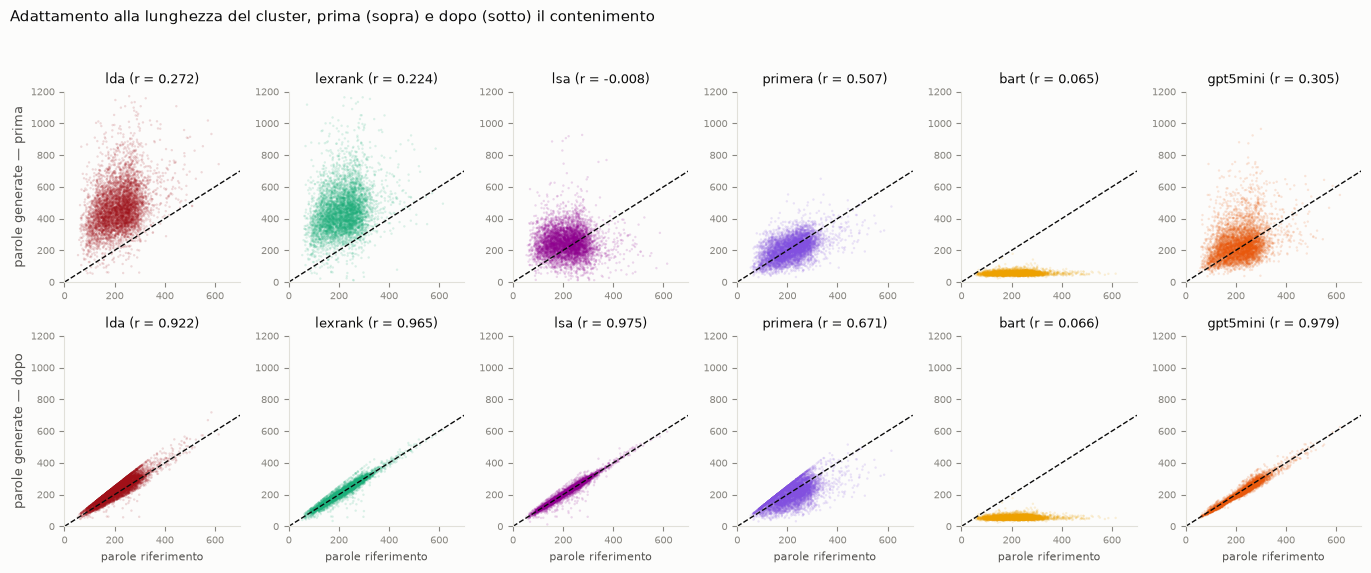

In [9]:
campione = [m for m in ('lda', 'lexrank', 'lsa', 'primera', 'bart', 'gpt5mini')
            if all(m in lunghezze[s] for s in SCOPI)]
if campione:
    fig, axes = plt.subplots(len(SCOPI), len(campione), figsize=(2.3 * len(campione), 2.9 * len(SCOPI)),
                             facecolor=SURFACE, squeeze=False)
    for riga_ax, (scope, ruolo) in zip(axes, SCOPI.items()):
        a = analisi[scope]
        for ax, metodo in zip(riga_ax, campione):
            ax.set_facecolor(SURFACE)
            L = np.array([lunghezze[scope][metodo][r] for r in a['comuni']], dtype=np.float64)
            ax.scatter(a['R'], L, s=3, alpha=0.15, color=COLORI.get(metodo, '#457b9d'), edgecolors='none')
            ax.plot([0, 700], [0, 700], color=INK, lw=1, ls='--')
            r = a['per_metodo'][metodo]['corr_len_riferimento']
            ax.set_title(f'{metodo} (r = {r})', color=INK, fontsize=9)
            ax.set_xlim(0, 700)
            ax.set_ylim(0, 1200)
            ax.tick_params(colors=MUTED, labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)
        riga_ax[0].set_ylabel(f'parole generate — {ruolo}', color=INK2, fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel('parole riferimento', color=INK2, fontsize=8)
    fig.suptitle('Adattamento alla lunghezza del cluster, prima (sopra) e dopo (sotto) il contenimento',
                 color=INK, x=0.01, ha='left', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Vista 5 — Quale budget per cluster? Confronto dei predittori

Il contenimento ha bisogno di un budget di parole per ogni cluster. La Vista 2 suggerisce
`T(n_articoli)`; ma quanto *aiuta davvero* conoscere il numero di articoli — o la lunghezza
della sorgente, o entrambi — a prevedere la lunghezza del riferimento di un singolo cluster?

Qui ogni candidato viene **tarato sulla split train** e valutato **sulla split test**: errore
assoluto medio in parole, errore percentuale mediano, quota di cluster il cui riferimento cade
nella banda `[0,80, 1,25] × budget`, e correlazione di rango fra budget e riferimento (quanto il
budget *ordina* bene i cluster). Due estremi fanno da riferimento: un budget **costante** (la
mediana di train, nessuna informazione dal cluster) e l'**oracolo** (il riferimento stesso, il
massimo raggiungibile).


In [10]:
def colonne(righe_split):
    a = np.array([(n, rif, src) for _, n, rif, src in righe_split], dtype=np.float64)
    return a[:, 0], a[:, 1], a[:, 2]          # n_articoli, parole_riferimento, parole_sorgente

na_tr, tw_tr, sw_tr = colonne(righe['train'])
na_te, tw_te, sw_te = colonne(righe[SPLIT_RIFERIMENTI])
ok_tr = (sw_tr > 0) & (tw_tr > 0)


def mediana_per_gruppo(chiavi_tr, y_tr, chiavi):
    """Mediana di y per gruppo, tarata su train e applicata alle chiavi richieste."""
    tab = {k: float(np.median(y_tr[chiavi_tr == k])) for k in np.unique(chiavi_tr)}
    default = float(np.median(list(tab.values())))
    return np.array([tab.get(k, default) for k in chiavi])


def bin_quantili(x_tr, x, n_bin):
    edges = np.quantile(x_tr, np.linspace(0, 1, n_bin + 1)[1:-1])
    return np.searchsorted(edges, x)


def spearman(x, y):
    rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx, ry)[0, 1])


candidati = {}
# A. costante: la mediana di train, nessuna informazione dal cluster
candidati['A  costante (mediana train)'] = np.full_like(tw_te, np.median(tw_tr))
# B. mediana per numero di articoli — la T(n_articoli) della Vista 2
b_tr, b_te = np.minimum(na_tr, BUCKET_MASSIMO), np.minimum(na_te, BUCKET_MASSIMO)
candidati['B  mediana per n_articoli (T)'] = mediana_per_gruppo(b_tr, tw_tr, b_te)
# C1. mediana per decile di lunghezza della sorgente
candidati['C1 mediana per 10 decili di parole sorgente'] = mediana_per_gruppo(
    bin_quantili(sw_tr, sw_tr, 10), tw_tr, bin_quantili(sw_tr, sw_te, 10))
# C2. regressione log-log riferimento ~ sorgente
b, a = np.polyfit(np.log(sw_tr[ok_tr]), np.log(tw_tr[ok_tr]), 1)
candidati[f'C2 log-log riferimento ~ sorgente (esp. {b:.2f})'] = np.exp(a + b * np.log(np.maximum(sw_te, 1)))
# C3. compressione costante: riferimento = sorgente / mediana(sorgente/riferimento)
c = float(np.median(sw_tr[ok_tr] / tw_tr[ok_tr]))
candidati[f'C3 sorgente / compressione mediana ({c:.1f})'] = sw_te / c
# D. mediana per (n_articoli, terzile di sorgente dentro il bucket)
edges = {k: np.quantile(sw_tr[b_tr == k], [1/3, 2/3]) for k in np.unique(b_tr)}
def chiave_D(bk, sw):
    return np.array([k * 10 + int(np.searchsorted(edges[k], s)) for k, s in zip(bk, sw)])
candidati['D  mediana per n_articoli x terzile sorgente'] = mediana_per_gruppo(
    chiave_D(b_tr, sw_tr), tw_tr, chiave_D(b_te, sw_te))
# E. regressione log-log con entrambi
X = np.column_stack([np.ones(ok_tr.sum()), np.log(sw_tr[ok_tr]), np.log(na_tr[ok_tr])])
coef, *_ = np.linalg.lstsq(X, np.log(tw_tr[ok_tr]), rcond=None)
Xte = np.column_stack([np.ones(len(sw_te)), np.log(np.maximum(sw_te, 1)), np.log(na_te)])
candidati[f'E  log-log riferimento ~ sorgente + n_articoli'] = np.exp(Xte @ coef)
# F. oracolo: il riferimento stesso (limite superiore, NON un budget utilizzabile in produzione)
candidati['F  oracolo = lunghezza del riferimento'] = tw_te.copy()

righe_confronto = {}
for nome, pred in candidati.items():
    pred = np.maximum(pred, 1)
    righe_confronto[nome] = {
        'MAE (parole)': round(float(np.mean(np.abs(pred - tw_te))), 1),
        'APE mediano %': round(float(np.median(np.abs(pred - tw_te) / np.maximum(tw_te, 1)) * 100), 1),
        'riferimento in banda %': round(float(np.mean((tw_te >= BANDA[0] * pred)
                                                       & (tw_te <= BANDA[1] * pred)) * 100), 1),
        'spearman': round(spearman(pred, tw_te), 3) if np.std(pred) > 0 else None,
    }
confronto_budget = pd.DataFrame(righe_confronto).T
display(confronto_budget)


,MAE (parole),APE mediano %,riferimento in banda %,spearman
A costante (mediana train),53.2,20.0,54.2,NaN
B mediana per n_articoli (T),48.1,19.0,56.7,0.362
C1 mediana per 10 decili di parole sorgente,48.0,18.4,57.7,0.402
C2 log-log riferimento ~ sorgente (esp. 0.18),48.6,19.4,55.2,0.407
C3 sorgente / compressione mediana (6.4),137.7,41.3,27.6,0.407
D mediana per n_articoli x terzile sorgente,46.5,18.4,58.0,0.436
E log-log riferimento ~ sorgente + n_articoli,46.7,18.8,56.7,0.457
F oracolo = lunghezza del riferimento,0.0,0.0,100.0,1.000


### Che cosa dice il confronto

1. **Niente di calcolabile dal solo input prevede bene la lunghezza del riferimento.** Il miglior
   candidato non-oracolo (D, numero di articoli × terzile di sorgente) mette il riferimento in
   banda nel ~58% dei cluster; un budget **costante** lo fa nel ~54%. Tutta la macchina
   per-cluster — tabelle, bucket, regressioni — compra 2–4 punti percentuali, e la correlazione
   di rango non supera 0,46. La lunghezza del riferimento è in larga parte una scelta
   idiosincratica di chi lo ha scritto, non una funzione del cluster.
2. **`T(n_articoli)` era una motivazione sopravvalutata.** Che le *mediane* per bucket vadano da
   ~164 a ~327 parole è vero, ma la dispersione dentro ogni bucket è tale che conoscere il bucket
   aiuta poco per il singolo cluster (Spearman 0,36). E l'81% dei cluster di test ha 2–3
   articoli, dove `T` vale 194–232 ≈ la costante: la tabella «fa qualcosa» solo nella coda.
3. **L'idea intuitiva «scala con la lunghezza della sorgente» (C3) è proprio sbagliata**: MAE
   ~138 parole, perché il rapporto di compressione varia di 5× fra cluster (p25 4,0 → p75 9,8).

**Conseguenza per il contenimento.** Lo scopo del budget è dare a ogni metodo *lo stesso*
bersaglio per cluster, così che il confronto non dipenda dalla lunghezza; quanto quel bersaglio
somigli al riferimento conta solo per la fedeltà dei numeri assoluti. Su questo il confronto è
netto: fra i budget non-oracolo il costante è già quasi ottimo, e il candidato che davvero
elimina la lunghezza come confondente è l'**oracolo (F)** — il riferimento stesso, cluster per
cluster. Con `|candidato| ≈ |riferimento|` il richiamo ROUGE e la precisione coincidono e
l'obiezione «i riassunti lunghi vincono sul recall» non può più nascere per costruzione. È il
protocollo *length-matched* / *oracle-length* della letteratura (es. Sun et al., 2019): usa
un'informazione gold — la sola **lunghezza**, mai il contenuto — e va dichiarato come tale,
perché risponde a «quanto è buona la selezione dei contenuti a parità di lunghezza», non a «cosa
otterrebbe il metodo in produzione». La scelta e la sua applicazione ai 18 metodi sono
documentate nella [issue #16](https://github.com/girasella/multi-news-ai4stem-polito-master/issues/16).

**Esito del contenimento** (corse 2026-09-13/17, colonna «dopo» delle Viste 1 e 3): il rapporto
max/min mediano dentro il cluster passa da **8,5×** a 4,7× sui 18 metodi — ma quel 4,7 è quasi
tutto `bart`, l'eccezione dichiarata a solo tetto (0,26× il riferimento): **senza `bart` 3,8× →
1,6×, sui 15 rigenerati 3,7× → 1,4×**. I 15 rigenerati stanno in banda nel 71–100% dei cluster
(gli 11 estrattivi 93–99%, `gpt5mini` 100%, `gemma` 99%, `qwen` 79%, `mistral` 71%), con
lunghezza mediana pari al riferimento (~215 parole). La lettura delle metriche a lunghezza pari è
nei notebook [05c](05c_confronto_test_budgetref.ipynb) e [05d](05d_confronto_prima_dopo.ipynb).

## Salvataggio

L'analisi di ciascun ambito va in `results/metrics/analisi_lunghezze_{ambito}.json` (committato),
lo stesso pattern di `scripts/dataset_stats.json` per l'EDA del corpus: un unico oggetto JSON
per ambito che altri possono leggere senza rieseguire questo notebook (il notebook [05d](05d_confronto_prima_dopo.ipynb) ne
legge la quota in banda). Il file di `test_budgetref` porta in più, sotto
`rapporto_max_min_sottoinsiemi`, i rapporti max/min «senza bart» e «solo rigenerati», e sotto
`per_metodo_pre_tetto` le distribuzioni della Vista 3b (lunghezze prima del tetto, 15 metodi).


In [11]:
for scope in SCOPI:
    a = analisi[scope]
    risultato = {
        'scope': scope, 'split': SPLIT_RIFERIMENTI, 'banda': list(BANDA),
        'n_cluster': len(a['comuni']), 'metodi': a['metodi'],
        'riferimento': distribuzione(a['R'], 1),
        'n_articoli': distribuzione(a['A'], 2),
        'dispersione_per_cluster': a['dispersione'],
        'rapporto_max_min_sottoinsiemi': a['rapporto_sottoinsiemi'],
        'per_metodo': a['per_metodo'],
        **({'per_metodo_pre_tetto': pre_tetto} if scope == 'test_budgetref' and pre_tetto else {}),
        'tabella_budget': T, 'split_taratura_budget': 'train',
        'confronto_budget': {nome: v for nome, v in righe_confronto.items()},
    }
    out = P['metrics_dir'] / f'analisi_lunghezze_{scope}.json'
    out.write_text(json.dumps(risultato, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Analisi salvata: {out}')

Analisi salvata: C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\metrics\analisi_lunghezze_test.json
Analisi salvata: C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\metrics\analisi_lunghezze_test_budgetref.json
